# Визуализация данных

Проведём визуальный EDA датасета Wine: посмотрим распределения, различия между классами, связи признаков и корреляции.

In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

sns.set_theme(style="whitegrid")

In [2]:
data = pd.read_csv("train.csv")
data["class"] = data["target"].map({0: "class_0", 1: "class_1", 2: "class_2"})
display(data.head())
display(data.describe().T)
print("Пропуски:", int(data.isna().sum().sum()))

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,target,class
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0,0,class_0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0,0,class_0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0,0,class_0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0,0,class_0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0,0,class_0


,count,mean,std,min,25%,50%,75%,max
alcohol,178.0,13.000618,0.811827,11.03,12.3625,13.050,13.6775,14.83
malic_acid,178.0,2.336348,1.117146,0.74,1.6025,1.865,3.0825,5.80
ash,178.0,2.366517,0.274344,1.36,2.2100,2.360,2.5575,3.23
alcalinity_of_ash,178.0,19.494944,3.339564,10.60,17.2000,19.500,21.5000,30.00
magnesium,178.0,99.741573,14.282484,70.00,88.0000,98.000,107.0000,162.00
total_phenols,178.0,2.295112,0.625851,0.98,1.7425,2.355,2.8000,3.88
flavanoids,178.0,2.029270,0.998859,0.34,1.2050,2.135,2.8750,5.08
nonflavanoid_phenols,178.0,0.361854,0.124453,0.13,0.2700,0.340,0.4375,0.66
proanthocyanins,178.0,1.590899,0.572359,0.41,1.2500,1.555,1.9500,3.58
color_intensity,178.0,5.058090,2.318286,1.28,3.2200,4.690,6.2000,13.00


Пропуски: 0


## Распределения

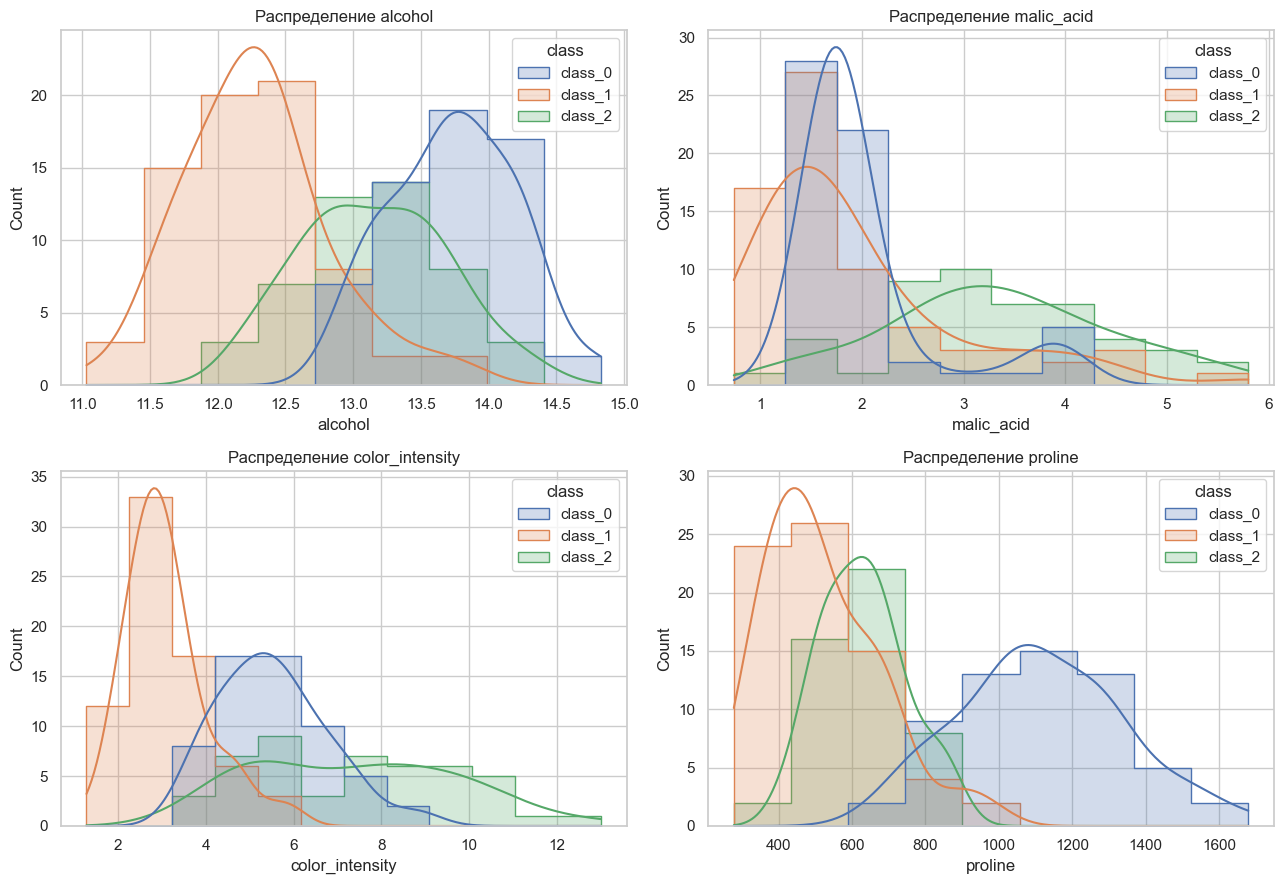

In [3]:
columns = ["alcohol", "malic_acid", "color_intensity", "proline"]
fig, axes = plt.subplots(2, 2, figsize=(13, 9))
for column, axis in zip(columns, axes.ravel()):
    sns.histplot(data=data, x=column, hue="class", kde=True, element="step", ax=axis)
    axis.set_title(f"Распределение {column}")
plt.tight_layout()
plt.show()

## Сравнение классов

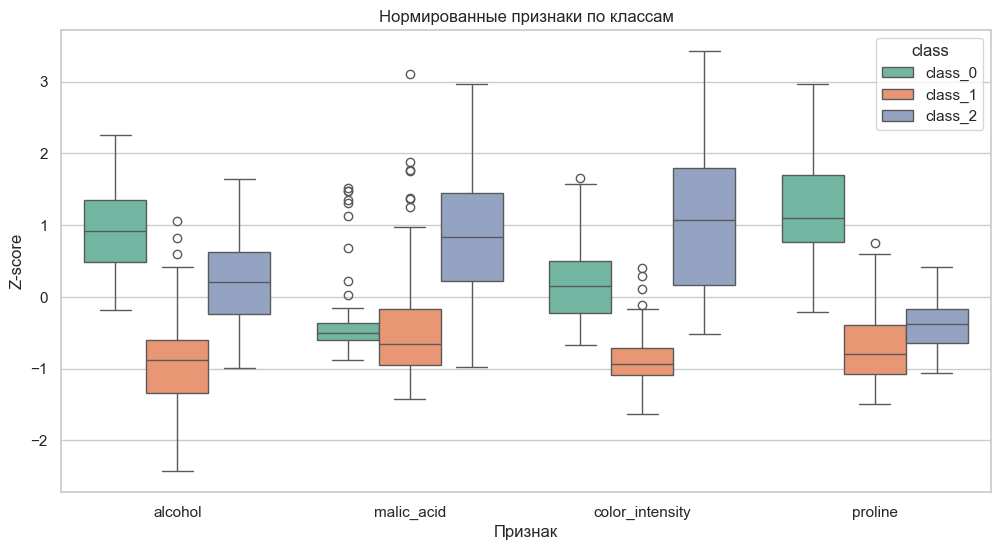

In [4]:
melted = data.melt(id_vars="class", value_vars=columns, var_name="feature", value_name="value")
normalized = melted.copy()
normalized["value"] = normalized.groupby("feature")["value"].transform(
    lambda series: (series - series.mean()) / series.std()
)

plt.figure(figsize=(12, 6))
sns.boxplot(data=normalized, x="feature", y="value", hue="class", palette="Set2")
plt.title("Нормированные признаки по классам")
plt.xlabel("Признак")
plt.ylabel("Z-score")
plt.show()

## Связи и корреляции

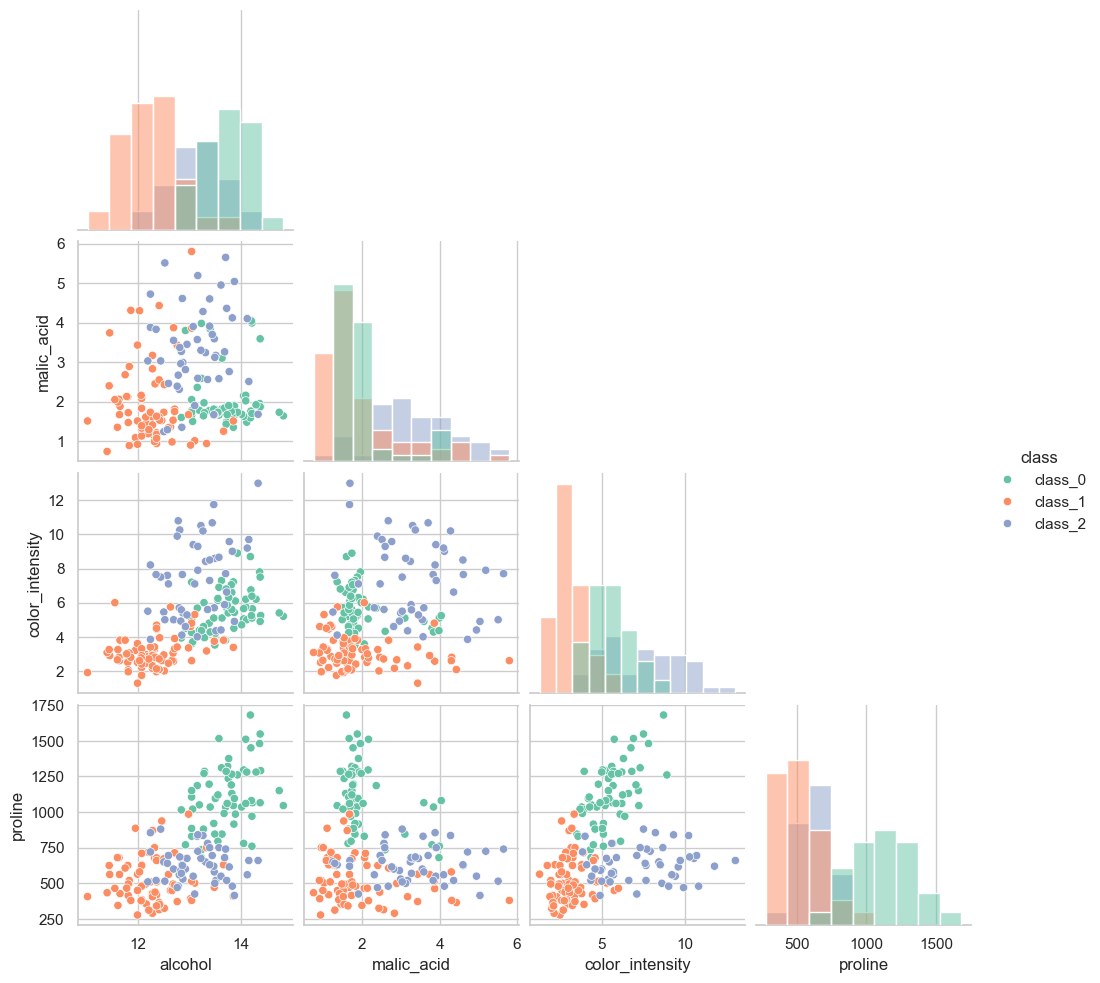

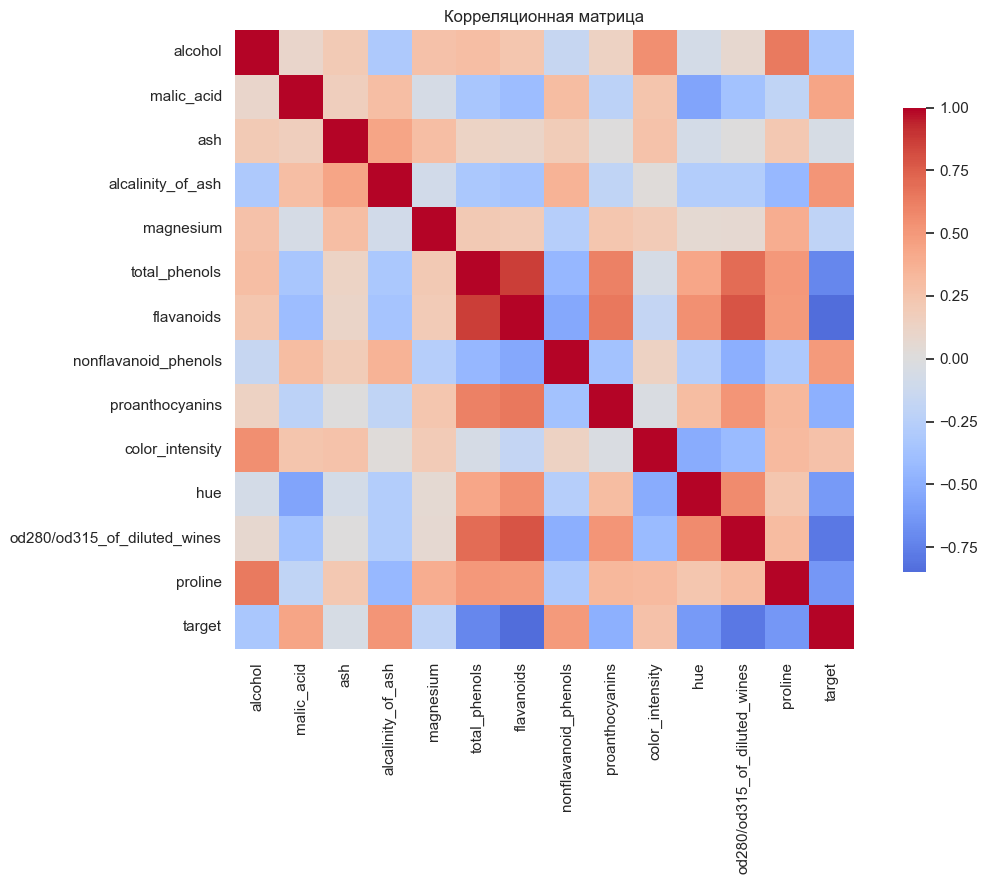

In [5]:
sns.pairplot(data, vars=columns, hue="class", corner=True, diag_kind="hist", palette="Set2")
plt.show()

plt.figure(figsize=(12, 9))
sns.heatmap(data.drop(columns="class").corr(), cmap="coolwarm", center=0, square=True, cbar_kws={"shrink": 0.75})
plt.title("Корреляционная матрица")
plt.tight_layout()
plt.show()

## Вывод

Визуализация помогает обнаружить асимметрию, выбросы, различия между классами и коррелирующие признаки. Эти наблюдения определяют дальнейшую предобработку и выбор модели.